In [78]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from functools import reduce
import numpy as np
import pandas as pd
import re
import gc
import datetime as _dt
import pyarrow.parquet as pq
from collections import defaultdict
from dateutil.relativedelta import relativedelta
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler,MinMaxScaler
from sklearn.metrics import precision_recall_curve, auc
from sklearn.neighbors import NearestNeighbors
from deap import base, creator, tools, algorithms
import torch
from torch_geometric.data import Data
from torch_geometric.nn import RGCNConv
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import torch.nn.functional as F

In [79]:
features_users = pd.read_csv('features_v3.csv')
features_users.head()

,user,email_external_ratio,email_suspicious_content_ratio,email_bcc_email_ratio,email_external_email_with_attachment_ratio,email_after_hours_or_weekend_ratio,email_max_zscore_emails,email_avg_emails_per_week,email_avg_size_sent_email,email_zscore_last_month,...,http_download_ratio,http_off_hours_ratio,http_last_month_zscore,http_max_zscore_activity,http_sus_domain_ratio,http_unique_domains,http_job_search_score,users_post_departure_activity,users_pre_departure_ratio,users_activity_not_main_pc_ratio
0,AAB0162,0.307374,0.014940,0.0,0.051176,0.000000,0.0,42.513514,1.994349e+05,-0.871931,...,0.0,0.0000,0.0,0.0,0.0318,126,0.0699,0.0,0.000000,0.0
1,AAB0398,0.383626,0.003674,0.0,0.118079,0.056416,0.0,51.500000,3.568791e+05,-0.095175,...,0.0,0.0474,0.0,0.0,0.0308,248,0.0133,0.0,0.000000,0.0
2,AAC0610,0.363118,0.009506,0.0,0.132129,0.000000,0.0,14.216216,8.273392e+05,0.315768,...,0.0,0.0096,0.0,0.0,0.1031,200,0.0189,0.0,0.001404,0.0
3,AAC0668,0.350562,0.007705,0.0,0.070305,0.000000,0.0,42.094595,4.068177e+05,0.439913,...,0.0,0.0000,0.0,0.0,0.0342,175,0.0548,0.0,0.000000,0.0
4,AAC3270,0.258721,0.000000,0.0,0.139535,0.000000,0.0,4.648649,1.333953e+06,0.901975,...,0.0,0.0000,0.0,0.0,0.0000,55,0.0045,0.0,0.000000,0.0


In [80]:
df_users = pd.read_parquet('cert_dataset/users.parquet')
df_users = df_users.rename(columns={'user_id':'user'})
df_users.head()

,employee_name,user,email,role,projects,business_unit,functional_unit,department,team,supervisor,start_date,end_date
0,Nicholas Fletcher Pruitt,NFP2441,Nicholas.Fletcher.Pruitt@dtaa.com,ITAdmin,None,1,1 - Adminstration,5 - Security,8 - ElectronicSecurity,Madison Charissa Malone,2009-12-01 00:00:00,2011-06-01
1,Abraham Dante Rodgers,ADR1517,Abraham.Dante.Rodgers@dtaa.com,ProductionLineWorker,None,1,5 - Manufacturing_Commercial,3 - Assembly,4 - AssemblyDept,Mark William Horne,2009-12-01 00:00:00,2011-06-01
2,Medge Wilma Blackburn,MWB4000,Medge.Wilma.Blackburn@dtaa.com,ProductionLineWorker,None,1,6 - Manufacturing_Government,3 - Assembly,14 - AssemblyDept,Hillary Zenaida Adkins,2009-12-01 00:00:00,2011-06-01
3,Meghan Laurel Salazar,MLS2856,Meghan.Laurel.Salazar@dtaa.com,ProductionLineWorker,None,1,6 - Manufacturing_Government,3 - Assembly,8 - AssemblyDept,Demetria Sage Melendez,2009-12-01 00:00:00,2011-06-01
4,Beau Todd Romero,BTR2026,Beau.Todd.Romero@dtaa.com,MechanicalEngineer,None,1,3 - ResearchAndEngineering_Government_Domestic,4 - Engineering,16 - TestAndEvalualtion,Elijah Valentine Fuentes,2009-12-01 00:00:00,2011-06-01


In [81]:
df = features_users.merge(df_users[['user','supervisor']],on='user',how='left')
df.reset_index(drop=True)
df.head()

,user,email_external_ratio,email_suspicious_content_ratio,email_bcc_email_ratio,email_external_email_with_attachment_ratio,email_after_hours_or_weekend_ratio,email_max_zscore_emails,email_avg_emails_per_week,email_avg_size_sent_email,email_zscore_last_month,...,http_off_hours_ratio,http_last_month_zscore,http_max_zscore_activity,http_sus_domain_ratio,http_unique_domains,http_job_search_score,users_post_departure_activity,users_pre_departure_ratio,users_activity_not_main_pc_ratio,supervisor
0,AAB0162,0.307374,0.014940,0.0,0.051176,0.000000,0.0,42.513514,1.994349e+05,-0.871931,...,0.0000,0.0,0.0,0.0318,126,0.0699,0.0,0.000000,0.0,Jeanette Macey Simpson
1,AAB0398,0.383626,0.003674,0.0,0.118079,0.056416,0.0,51.500000,3.568791e+05,-0.095175,...,0.0474,0.0,0.0,0.0308,248,0.0133,0.0,0.000000,0.0,Deborah Madaline Horton
2,AAC0610,0.363118,0.009506,0.0,0.132129,0.000000,0.0,14.216216,8.273392e+05,0.315768,...,0.0096,0.0,0.0,0.1031,200,0.0189,0.0,0.001404,0.0,Ann Tamekah Daniels
3,AAC0668,0.350562,0.007705,0.0,0.070305,0.000000,0.0,42.094595,4.068177e+05,0.439913,...,0.0000,0.0,0.0,0.0342,175,0.0548,0.0,0.000000,0.0,Grace Jasmine Gamble
4,AAC3270,0.258721,0.000000,0.0,0.139535,0.000000,0.0,4.648649,1.333953e+06,0.901975,...,0.0000,0.0,0.0,0.0000,55,0.0045,0.0,0.000000,0.0,Quincy Guy Shannon


In [82]:
df['node_id'] = df.index

meta_cols = ['user','supervisor']  
feature_cols = [c for c in df.columns if c not in meta_cols]


print(f"Nombre de nœuds : {len(df)}")
print(f"Nombre de features : {len(feature_cols)}")

Nombre de nœuds : 4000
Nombre de features : 54


In [83]:
scaler = StandardScaler()
X = scaler.fit_transform(df[feature_cols].values)

In [84]:
# Construction des arêtes de pairs (même superviseur)
edges_peer = []

df_with_sup = df[df['supervisor'].notna()]

for (sup), group in df_with_sup.groupby(['supervisor']):
    node_ids = group['node_id'].values
    if len(node_ids) < 2:
        continue
    
    for i in range(len(node_ids)):
        for j in range(i+1, len(node_ids)):
            edges_peer.append((node_ids[i], node_ids[j]))
            edges_peer.append((node_ids[j], node_ids[i]))  
             

edges_peer = np.array(edges_peer).T  
print(f"Nombre d'arêtes de pairs : {edges_peer.shape[1]}")

Nombre d'arêtes de pairs : 76018


In [85]:
# Construction des arêtes de k-NN (k users plus proches)
k = 3
edges_knn = []

node_ids = df['node_id'].values
    
nn_model = NearestNeighbors(n_neighbors = k+1,metric='cosine')

nn_model.fit(X) 

_, neighbor_positions = nn_model.kneighbors(X)

for i in range(len(node_ids)):
    source_node = node_ids[i]
    for pos in neighbor_positions[i,1:]:
        target_node = node_ids[pos]
        edges_knn.append((source_node,target_node))

             
edges_knn = np.array(edges_knn).T  
print(f"Nombre d'arêtes k-NN : {edges_knn.shape[1]}")

Nombre d'arêtes k-NN : 12000


In [86]:
# Rendre les arêtes symétriques par union
edges_set = set()
for i in range(edges_knn.shape[1]):
    src, dst = edges_knn[0, i], edges_knn[1, i]
    edges_set.add((src, dst))
    edges_set.add((dst, src))

edges_knn = np.array(list(edges_set)).T
print(f"Nombre d'arêtes k-NN après symétrisation : {edges_knn.shape[1]}")

Nombre d'arêtes k-NN après symétrisation : 17734


In [87]:
# Création du graphe

edge_index_peer = torch.tensor(edges_peer, dtype=torch.long)
edge_index_knn = torch.tensor(edges_knn, dtype=torch.long)

edge_index = torch.cat([edge_index_peer, edge_index_knn], dim=1)

edge_type = torch.cat([
    torch.zeros(edge_index_peer.shape[1],dtype=torch.long),
    torch.ones(edge_index_knn.shape[1],dtype=torch.long),
])

x = torch.tensor(X, dtype=torch.float)

data = Data(x=x,edge_index=edge_index,edge_type=edge_type)

data.num_relations = 3

print(data)
print(f"Nombre de nœuds : {data.num_nodes}")
print(f"Nombre d'arêtes total : {data.num_edges}")
print(f"Répartition : peer={(edge_type==0).sum()}, knn={(edge_type==1).sum()}")

Data(x=[4000, 54], edge_index=[2, 93752], edge_type=[93752], num_relations=3)
Nombre de nœuds : 4000
Nombre d'arêtes total : 93752
Répartition : peer=76018, knn=17734


In [88]:
# Architecture du RGCN

class RGCNAutoencoder(nn.Module):
    def __init__(self,in_channels,hidden_channels,out_channels,num_relations):
        super().__init__()

        self.conv1 = RGCNConv(in_channels,hidden_channels,num_relations,num_bases=2)
        self.conv2 = RGCNConv(hidden_channels,out_channels,num_relations,num_bases=2)

        self.decoder = nn.Sequential(
            nn.Linear(out_channels,hidden_channels),
            nn.ReLU(),
            nn.Linear(hidden_channels,in_channels)
        )

        self.dropout = nn.Dropout(p=0.2)

    def encode(self,x,edge_index,edge_type):
        h = self.conv1(x,edge_index,edge_type)
        h = F.relu(h)
        h = self.dropout(h)
        z = self.conv2(h,edge_index,edge_type)
        return z

    def decode_features(self,z):
        return self.decoder(z)

    def decode_links(self,z,edge_index):
        src, dst = edge_index
        return (z[src]*z[dst]).sum(dim=-1)

    def forward(self,x,edge_index,edge_type):
        z = self.encode(x,edge_index,edge_type)
        x_hat = self.decode_features(z)
        return z, x_hat

In [89]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = RGCNAutoencoder(
    in_channels=X.shape[1],
    hidden_channels=64,
    out_channels=16,
    num_relations=3
).to(device)

data = data.to(device)

n_params = sum(p.numel() for p in model.parameters())
print(f"Modèle créé avec {n_params:,} paramètres")
print(model)

Modèle créé avec 18,130 paramètres
RGCNAutoencoder(
  (conv1): RGCNConv(54, 64, num_relations=3)
  (conv2): RGCNConv(64, 16, num_relations=3)
  (decoder): Sequential(
    (0): Linear(in_features=16, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=54, bias=True)
  )
  (dropout): Dropout(p=0.2, inplace=False)
)


In [90]:
all_positive_edges = data.edge_index
num_nodes = data.num_nodes
num_pos_edges = all_positive_edges.shape[1]

print(f"Pool d'arêtes positives : {num_pos_edges:,}")

Pool d'arêtes positives : 93,752


In [91]:
optimizer = torch.optim.Adam(model.parameters(),lr=1e-3, weight_decay=1e-5)

num_epochs = 10000
alpha = 0.4 
num_neg_samples = 2048 

In [92]:
model.train()
losses_history = {'total': [], 'recon': [], 'link': []}

for epoch in range(num_epochs):
    optimizer.zero_grad()
    
    z, x_hat = model(data.x, data.edge_index, data.edge_type)
    
    loss_recon = F.mse_loss(x_hat, data.x)
    
    pos_idx = torch.randint(0, num_pos_edges, (num_neg_samples,), device=device)
    pos_edges = all_positive_edges[:, pos_idx] 

    neg_src = torch.randint(0, num_nodes, (num_neg_samples,), device=device)
    neg_dst = torch.randint(0, num_nodes, (num_neg_samples,), device=device)
    neg_edges = torch.stack([neg_src, neg_dst], dim=0)
    
    pos_scores = model.decode_links(z, pos_edges)
    neg_scores = model.decode_links(z, neg_edges)
    
    pos_labels = torch.ones_like(pos_scores)
    neg_labels = torch.zeros_like(neg_scores)
    
    loss_link = F.binary_cross_entropy_with_logits(
        torch.cat([pos_scores, neg_scores]),
        torch.cat([pos_labels, neg_labels])
    )
    
    loss = alpha * loss_recon + (1 - alpha) * loss_link
    
    loss.backward()
    optimizer.step()
    
    losses_history['total'].append(loss.item())
    losses_history['recon'].append(loss_recon.item())
    losses_history['link'].append(loss_link.item())
    
    if epoch % 10 == 0:
        print(f"Epoch {epoch:3d} | Loss total: {loss.item():.4f} | "
              f"Recon: {loss_recon.item():.4f} | Link: {loss_link.item():.4f}")

print("\nEntraînement terminé.")

Epoch   0 | Loss total: 6.8460 | Recon: 1.2449 | Link: 10.5801
Epoch  10 | Loss total: 1.7137 | Recon: 1.0138 | Link: 2.1802
Epoch  20 | Loss total: 1.2725 | Recon: 0.9800 | Link: 1.4675
Epoch  30 | Loss total: 1.1216 | Recon: 0.9541 | Link: 1.2333
Epoch  40 | Loss total: 1.0141 | Recon: 0.9297 | Link: 1.0704
Epoch  50 | Loss total: 0.9199 | Recon: 0.9180 | Link: 0.9212
Epoch  60 | Loss total: 0.9149 | Recon: 0.8999 | Link: 0.9249
Epoch  70 | Loss total: 0.8828 | Recon: 0.8795 | Link: 0.8851
Epoch  80 | Loss total: 0.8254 | Recon: 0.8591 | Link: 0.8030
Epoch  90 | Loss total: 0.8245 | Recon: 0.8363 | Link: 0.8167
Epoch 100 | Loss total: 0.7921 | Recon: 0.8177 | Link: 0.7750
Epoch 110 | Loss total: 0.7612 | Recon: 0.7868 | Link: 0.7441
Epoch 120 | Loss total: 0.7427 | Recon: 0.7620 | Link: 0.7299
Epoch 130 | Loss total: 0.7268 | Recon: 0.7377 | Link: 0.7195
Epoch 140 | Loss total: 0.7115 | Recon: 0.7197 | Link: 0.7060
Epoch 150 | Loss total: 0.6955 | Recon: 0.7010 | Link: 0.6919
Epoch 1

In [93]:
model.eval()
with torch.no_grad():
    z_final = model.encode(data.x, data.edge_index, data.edge_type)

Z = z_final.cpu().numpy()
print(f"Shape des embeddings : {Z.shape}")
print(f"Statistiques des embeddings :")
print(f"  Mean : {Z.mean():.4f}")
print(f"  Std  : {Z.std():.4f}")
print(f"  Min  : {Z.min():.4f}")
print(f"  Max  : {Z.max():.4f}")

Shape des embeddings : (4000, 16)
Statistiques des embeddings :
  Mean : -0.0026
  Std  : 0.4515
  Min  : -2.1455
  Max  : 2.9193


In [94]:
iforest = IsolationForest(
    n_estimators=5000,
    max_samples=1024,
    contamination='auto',
    random_state=42,
    n_jobs=-1
)

iforest.fit(Z)

anomaly_scores = -iforest.score_samples(Z)
print(f"Shape des scores : {anomaly_scores.shape}")
print(f"Distribution des scores :")
print(f"  Min  : {anomaly_scores.min():.4f}")
print(f"  Max  : {anomaly_scores.max():.4f}")
print(f"  Mean : {anomaly_scores.mean():.4f}")

Shape des scores : (4000,)
Distribution des scores :
  Min  : 0.3733
  Max  : 0.6811
  Mean : 0.4264


In [95]:
l = pd.read_csv('cert_dataset/insiders/insiders.csv')
insiders_df = pd.DataFrame(l[l['dataset']==6.2]['user'])

insider_node_ids = []
for _, row in insiders_df.iterrows():
    matching = df[df['user'] == row['user']]
    if len(matching) > 0:
        insider_node_ids.append(matching['node_id'].values[0])

insider_node_ids = np.array(insider_node_ids)
print(f"Nombre d'insiders identifiées : {len(insider_node_ids)}")

Nombre d'insiders identifiées : 5


In [96]:
sorted_indices = np.argsort(-anomaly_scores)  
ranks = np.empty_like(sorted_indices)
ranks[sorted_indices] = np.arange(len(sorted_indices))

insider_ranks = ranks[insider_node_ids]
insider_scores = anomaly_scores[insider_node_ids]

ranking_table = pd.DataFrame({
    'node_id': insider_node_ids,
    'user': df.loc[insider_node_ids, 'user'].values,
    'anomaly_score': insider_scores,
    'rank': insider_ranks,
    'percentile': 100 * insider_ranks / len(anomaly_scores)
}).sort_values('rank').reset_index(drop=True)

print(f"Nombre total de nœuds : {len(anomaly_scores):,}")
print(f"Nombre d'insiders : {len(insider_node_ids)}\n")
print("Ranking des insiders (rang 0 = le plus anormal) :")
print(ranking_table.to_string(index=False))

Nombre total de nœuds : 4,000
Nombre d'insiders : 5

Ranking des insiders (rang 0 = le plus anormal) :
 node_id    user  anomaly_score  rank  percentile
      64 ACM2278       0.577732     6       0.150
     815 CMP2946       0.516999    44       1.100
    2987 PLJ1771       0.500002    71       1.775
     676 CDE1846       0.420337  2214      55.350
    2488 MBG3183       0.416565  2525      63.125


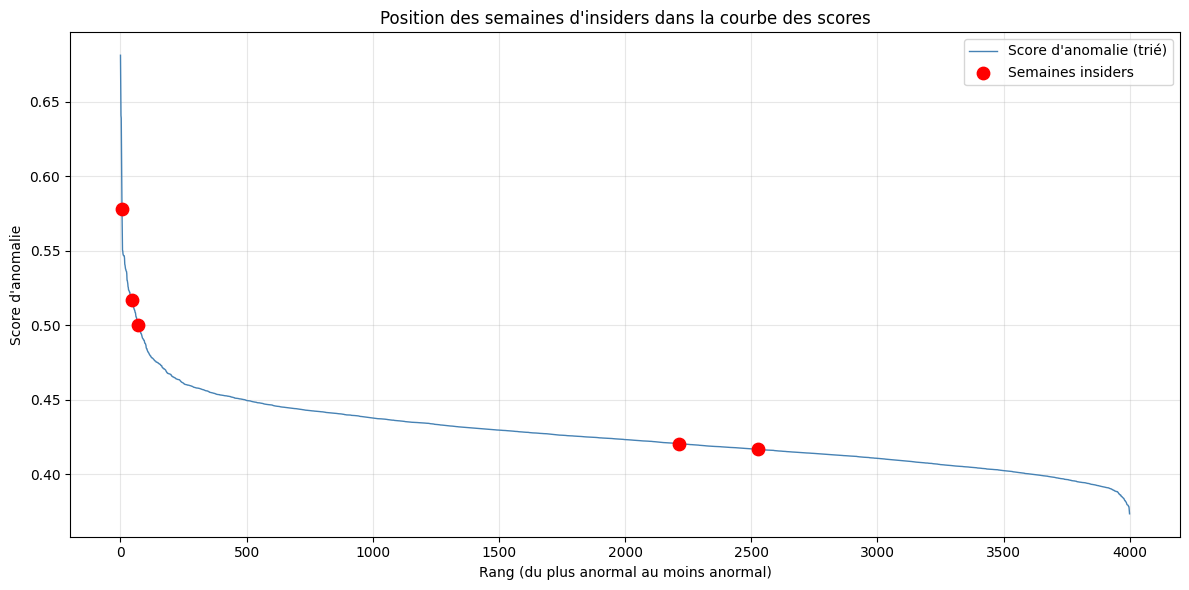

In [97]:
sorted_scores = anomaly_scores[sorted_indices]

plt.figure(figsize=(12, 6))
plt.plot(sorted_scores, color='steelblue', linewidth=1, label='Score d\'anomalie (trié)')
plt.scatter(insider_ranks, insider_scores, 
            color='red', s=80, zorder=5, label='Semaines insiders')

plt.xlabel('Rang (du plus anormal au moins anormal)')
plt.ylabel('Score d\'anomalie')
plt.title('Position des semaines d\'insiders dans la courbe des scores')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()